In [1]:
!ls /content/drive/MyDrive/Real_AI_SD_LD_Dataset.zip
!unzip /content/drive/MyDrive/Real_AI_SD_LD_Dataset.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/ukiyo_e/adachi-ginko_114.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_116.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_142.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_154.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_183.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_186.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_201.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_219.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_230.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_274.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_279.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_286.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_3.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_301.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_326.jpg  
  inflating: /content/train/ukiyo_e/adachi-ginko_385.jpg  
  infla

In [2]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
import os
train_dir = "/content/train"
test_dir = "/content/test"
def image_paths_and_labels(directory):
    image_paths = []
    labels = []

    for folder in sorted(os.listdir(directory)):
        folder_path = os.path.join(directory, folder)

        if folder.startswith("AI"):
            label = 0
        else:
            label = 1

        for img in sorted(os.listdir(folder_path)):
            image_paths.append(os.path.join(folder_path, img))
            labels.append(label)

    return image_paths, labels
train_paths, train_labels = image_paths_and_labels(train_dir)
test_paths, test_labels = image_paths_and_labels(test_dir)

print("Train images:", len(train_paths))
print("Test images:", len(test_paths))


Train images: 155015
Test images: 30000


In [4]:
from sklearn.model_selection import train_test_split
from collections import Counter
import random

SEED = 42
random.seed(SEED)

# ---------- SPLIT TRAIN → TRAIN + VAL ----------
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths,
    train_labels,
    test_size=0.2,
    stratify=train_labels,
    random_state=SEED
)

#dataset balancing
def balance_dataset(paths, labels):

    paths_ai = [p for p, l in zip(paths, labels) if l == 0]
    paths_human = [p for p, l in zip(paths, labels) if l == 1]

    min_count = min(len(paths_ai), len(paths_human))

    paths_ai = random.sample(paths_ai, min_count)
    paths_human = random.sample(paths_human, min_count)

    new_paths = paths_ai + paths_human
    new_labels = [0]*min_count + [1]*min_count

    combined = list(zip(new_paths, new_labels))
    random.shuffle(combined)

    new_paths, new_labels = zip(*combined)

    return list(new_paths), list(new_labels)


# balance train
train_paths, train_labels = balance_dataset(train_paths, train_labels)

# balance validation
val_paths, val_labels = balance_dataset(val_paths, val_labels)

# ---------- VERIFY ----------
print("Train:", Counter(train_labels))
print("Validation:", Counter(val_labels))
print("Test:", Counter(test_labels))

Train: Counter({1: 40000, 0: 40000})
Validation: Counter({1: 10000, 0: 10000})
Test: Counter({0: 20000, 1: 10000})


In [5]:
import tensorflow as tf
import numpy as np
import io
from PIL import Image, ImageChops, ImageEnhance, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

IMG_SIZE = 224
BATCH_SIZE = 16     # safer for dual-input model
AUTOTUNE = tf.data.AUTOTUNE


# ===== ELA FUNCTION =====
def convert_to_ela_path(path, quality=90):

    image = Image.open(path).convert("RGB")

    buffer = io.BytesIO()
    image.save(buffer, "JPEG", quality=quality)
    buffer.seek(0)

    compressed = Image.open(buffer)

    ela_image = ImageChops.difference(image, compressed)

    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])

    scale = 255.0 / max_diff if max_diff != 0 else 1

    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)

    ela_image = ela_image.resize((IMG_SIZE, IMG_SIZE))

    ela_array = np.array(ela_image) / 255.0

    return ela_array.astype("float32")


# ===== LOAD RGB + ELA =====
def load_pair(path, label):

    if isinstance(path, tf.Tensor):
        path = path.numpy().decode()

    # RGB image
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img) / 255.0

    # ELA image
    ela = convert_to_ela_path(path)

    return img.astype(np.float32), ela.astype(np.float32), label



def tf_load_pair(path, label):

    img, ela, label = tf.py_function(
        func=load_pair,
        inp=[path, label],
        Tout=[tf.float32, tf.float32, tf.int32]
    )

    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    ela.set_shape([IMG_SIZE, IMG_SIZE, 3])
    label.set_shape([])

    return (img, ela), label


# ===== DATASETS =====
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_dataset   = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_dataset  = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

train_dataset = train_dataset.shuffle(20000)

train_dataset = train_dataset.map(tf_load_pair, num_parallel_calls=AUTOTUNE)\
                             .batch(BATCH_SIZE)\
                             .prefetch(AUTOTUNE)

val_dataset = val_dataset.map(tf_load_pair, num_parallel_calls=AUTOTUNE)\
                         .batch(BATCH_SIZE)\
                         .prefetch(AUTOTUNE)

test_dataset = test_dataset.map(tf_load_pair, num_parallel_calls=AUTOTUNE)\
                           .batch(BATCH_SIZE)\
                           .prefetch(AUTOTUNE)


# ===== Debug =====
for (rgb, ela), labels in train_dataset.take(1):
    print("RGB batch:", rgb.shape)
    print("ELA batch:", ela.shape)
    print("Labels:", labels.shape)

RGB batch: (16, 224, 224, 3)
ELA batch: (16, 224, 224, 3)
Labels: (16,)


In [7]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random_index = random.randint(0, len(train_paths) - 1)
random_path = train_paths[random_index]



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

# ===== RGB INPUT =====
rgb_input = layers.Input(shape=(224,224,3), name="rgb_input")

rgb_base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=rgb_input
)

rgb_base.trainable = False

rgb_features = layers.GlobalAveragePooling2D()(rgb_base.output)


# ===== ELA INPUT =====
ela_input = layers.Input(shape=(224,224,3), name="ela_input")

x = layers.Conv2D(32, 3, activation="relu")(ela_input)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, activation="relu")(x)
x = layers.MaxPooling2D()(x)

ela_features = layers.GlobalAveragePooling2D()(x)


# ===== FUSION =====
combined = layers.Concatenate()([rgb_features, ela_features])

x = layers.BatchNormalization()(combined)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation="sigmoid")(x)


model = Model(
    inputs=[rgb_input, ela_input],
    outputs=output
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ rgb_input[0][0]   │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,418,916 (16.86 MB)

 Trainable params: 366,657 (1.40 MB)

 Non-trainable params: 4,052,259 (15.46 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=6,
    steps_per_epoch=150,
    validation_steps=40,
    callbacks=[early_stop, reduce_lr]
)

print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Epoch 1/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 110s 508ms/step - accuracy: 0.7054 - loss: 0.5647 - val_accuracy: 0.6578 - val_loss: 0.6428 - learning_rate: 1.0000e-04
Epoch 2/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 66s 442ms/step - accuracy: 0.7767 - loss: 0.4756 - val_accuracy: 0.8219 - val_loss: 0.5764 - learning_rate: 1.0000e-04
Epoch 3/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 68s 453ms/step - accuracy: 0.8033 - loss: 0.4428 - val_accuracy: 0.8375 - val_loss: 0.4763 - learning_rate: 1.0000e-04
Epoch 4/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 66s 445ms/step - accuracy: 0.8325 - loss: 0.3824 - val_accuracy: 0.8344 - val_loss: 0.3909 - learning_rate: 1.0000e-04
Epoch 5/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 68s 456ms/step - accuracy: 0.8567 - loss: 0.3407 - val_accuracy: 0.8938 - val_loss: 0.2898 - learning_rate: 1.0000e-04
Epoch 6/6
150/150 ━━━━━━━━━━━━━━━━━━━━ 65s 436ms/step - accuracy: 0.8796 - loss: 0.3013 - val_accuracy: 0.9047 - val_loss: 0.2381 - learning_rate: 1.0000e-04
Final Training Accuracy: 0.8795833587646484
Final V

In [ ]:
# ===== FINE-TUNING (UNFREEZE TOP LAYERS) =====

import tensorflow as tf

# 1️⃣ Unfreeze top part of the model
for layer in model.layers[-120:]:   # adjust 80–150 if needed
    layer.trainable = True

print("Top layers unfrozen ✅")

# 2️⃣ Recompile with LOW learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # very important
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning ✅")

# 3️⃣ Continue training
history_ft = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,                 # small number is enough
    steps_per_epoch=150,
    validation_steps=40,
    callbacks=[early_stop, reduce_lr]
)

print("Fine-tuning completed 🚀")

Top layers unfrozen ✅
Model recompiled for fine-tuning ✅
Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 124s 511ms/step - accuracy: 0.8254 - loss: 0.3931 - val_accuracy: 0.8531 - val_loss: 0.3358 - learning_rate: 1.0000e-05
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 518ms/step - accuracy: 0.8367 - loss: 0.3705 - val_accuracy: 0.8891 - val_loss: 0.2700 - learning_rate: 1.0000e-05
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 462ms/step - accuracy: 0.8646 - loss: 0.3279 - val_accuracy: 0.9141 - val_loss: 0.2304 - learning_rate: 1.0000e-05
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 68s 458ms/step - accuracy: 0.8612 - loss: 0.3235 - val_accuracy: 0.9000 - val_loss: 0.2520 - learning_rate: 1.0000e-05
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 68s 458ms/step - accuracy: 0.8654 - loss: 0.3217 - val_accuracy: 0.9187 - val_loss: 0.1963 - learning_rate: 1.0000e-05
Fine-tuning completed 🚀


In [ ]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Final Test Accuracy:", test_acc)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 723s 386ms/step - accuracy: 0.9346 - loss: 0.1906
Final Test Accuracy: 0.9345999956130981


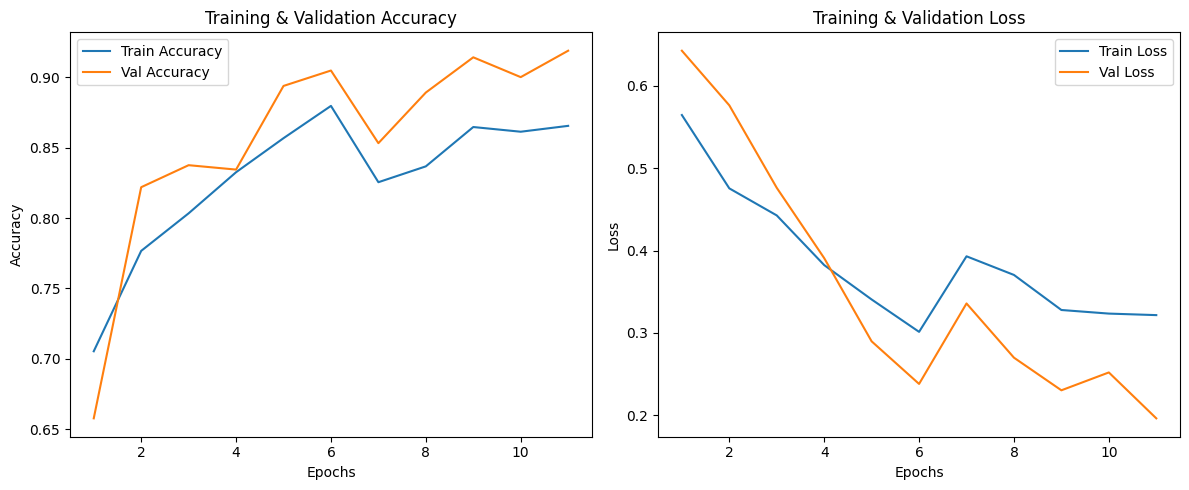

In [ ]:
import matplotlib.pyplot as plt

def plot_combined_history(history, history_ft):
    acc = history.history['accuracy'] + history_ft.history['accuracy']
    val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']

    loss = history.history['loss'] + history_ft.history['loss']
    val_loss = history.history['val_loss'] + history_ft.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Val Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call
plot_combined_history(history, history_ft)

In [ ]:
import numpy as np

y_true = []
y_pred_prob = []

for (rgb, ela), labels in test_dataset:
    preds = model.predict([rgb, ela], verbose=0)

    y_true.extend(labels.numpy())
    y_pred_prob.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Convert to binary labels
y_pred = (y_pred_prob > 0.5).astype(int)

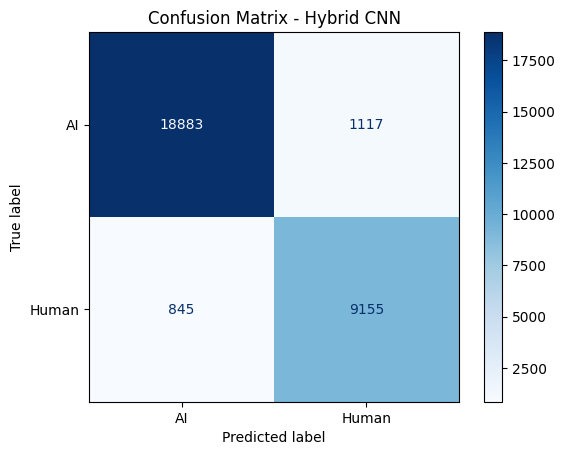

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["AI", "Human"]   # IMPORTANT: match your labeling
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Hybrid CNN")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Human", "AI"]
))

Classification Report:

              precision    recall  f1-score   support

       Human       0.96      0.94      0.95     20000
          AI       0.89      0.92      0.90     10000

    accuracy                           0.93     30000
   macro avg       0.92      0.93      0.93     30000
weighted avg       0.94      0.93      0.93     30000



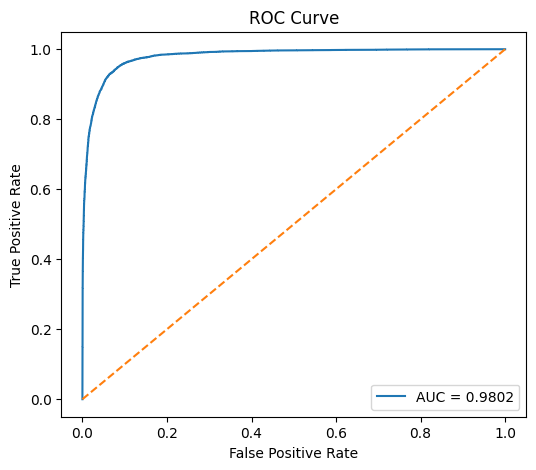

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
print(f"AUC Score: {roc_auc:.4f}")

AUC Score: 0.9802


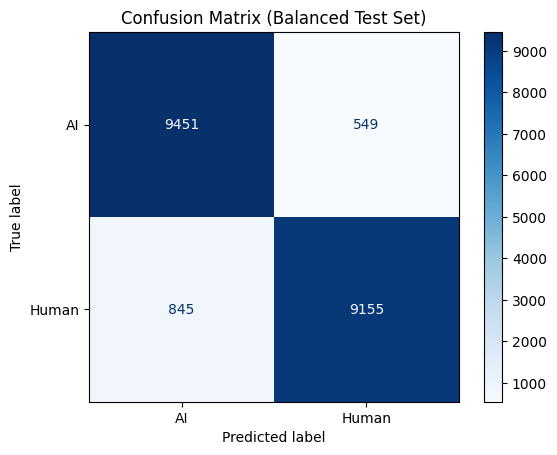

In [ ]:
# ===== BALANCE TEST DATA =====
test_paths_bal, test_labels_bal = balance_dataset(test_paths, test_labels)

# ===== CREATE BALANCED DATASET =====
test_dataset_bal = tf.data.Dataset.from_tensor_slices(
    (test_paths_bal, test_labels_bal)
)

test_dataset_bal = test_dataset_bal.map(
    tf_load_pair,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE)

# ===== GET PREDICTIONS =====
import numpy as np

y_true = []
y_pred = []

for (rgb, ela), labels in test_dataset_bal:
    preds = model.predict([rgb, ela], verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((preds.flatten() > 0.5).astype(int))

# ===== CONFUSION MATRIX =====
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["AI", "Human"]
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Balanced Test Set)")
plt.show()

In [8]:
from tensorflow import keras

model = keras.models.load_model('/content/drive/MyDrive/my_model.keras')

In [9]:
import gradio as gr
import numpy as np
from PIL import Image, ImageChops, ImageEnhance
import io

IMG_SIZE = 224


# ===== ELA FUNCTION =====
def convert_to_ela_pil(image, quality=90):

    buffer = io.BytesIO()
    image.save(buffer, "JPEG", quality=quality)
    buffer.seek(0)

    compressed = Image.open(buffer)

    ela_image = ImageChops.difference(image, compressed)

    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])

    scale = 255.0 / max_diff if max_diff != 0 else 1

    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)

    ela_image = ela_image.resize((IMG_SIZE, IMG_SIZE))

    return ela_image


# ===== PREDICTION FUNCTION =====
def predict_image(input_image):

    if input_image is None:
        return "Please upload an image"

    image = input_image.convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))

    # RGB input
    rgb_array = np.array(image) / 255.0
    rgb_array = np.expand_dims(rgb_array, axis=0).astype("float32")

    # ELA input
    ela_image = convert_to_ela_pil(image)
    ela_array = np.array(ela_image) / 255.0
    ela_array = np.expand_dims(ela_array, axis=0).astype("float32")

    # Predict
    prediction = model.predict([rgb_array, ela_array], verbose=0)[0][0]

    # IMPORTANT — based on your labeling:
    # 0 = AI, 1 = Human

    THRESHOLD = 0.09
    print(prediction)

    if prediction >= THRESHOLD:
        label = "🧑 Human Made"
        confidence = prediction
    else:
        label = "🤖 AI Generated"
        confidence = 1 - prediction

    return f"{label}\nConfidence: {confidence:.2%}{prediction}"


# ===== GRADIO GUI =====
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="AI vs Human Image Detector",
    description="Upload an image to check if it is AI-generated or human-made."
)

interface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://090d4a61806391a997.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


0.101834655
0.07151409
0.025531957
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://090d4a61806391a997.gradio.live


In [10]:
# ========== GRAD-CAM SETUP ==========
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image, ImageChops, ImageEnhance
import io

IMG_SIZE = 224

def convert_to_ela_pil(image, quality=90):
    buffer = io.BytesIO()
    image.save(buffer, "JPEG", quality=quality)
    buffer.seek(0)
    compressed = Image.open(buffer)
    ela_image = ImageChops.difference(image, compressed)
    extrema = ela_image.getextrema()
    max_diff = max(ex[1] for ex in extrema)
    scale = 255.0 / max_diff if max_diff != 0 else 1.0
    from PIL import ImageEnhance
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
    return ela_image

def preprocess_image(image_path):
    pil_img = Image.open(image_path).convert("RGB")
    pil_ela = convert_to_ela_pil(pil_img)
    def to_tensor(pil):
        arr = np.array(pil.resize((IMG_SIZE, IMG_SIZE))).astype("float32") / 255.0
        return tf.expand_dims(arr, axis=0)
    return to_tensor(pil_img), to_tensor(pil_ela), pil_img

def get_last_conv_layer(branch_model):
    for layer in reversed(branch_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found.")

def overlay_heatmap(heatmap, original_image, alpha=0.45):
    h, w = original_image.shape[:2]
    heatmap_resized = np.array(
        Image.fromarray(np.uint8(255 * heatmap)).resize((w, h), Image.BILINEAR)
    )
    colored = np.uint8(cm.get_cmap("jet")(heatmap_resized / 255.0)[:, :, :3] * 255)
    return np.uint8(colored * alpha + np.uint8(original_image) * (1 - alpha))

In [11]:
def gradcam_dual_input(model, image_path, alpha=0.45, save_path=None):

    # ── Preprocess EXACTLY like your Gradio code ──
    pil_original = Image.open(image_path).convert("RGB")
    image = pil_original.resize((IMG_SIZE, IMG_SIZE))   # resize FIRST

    # RGB input
    rgb_array = np.array(image) / 255.0
    rgb_tensor = np.expand_dims(rgb_array, axis=0).astype("float32")

    # ELA input (on already-resized image, same as Gradio)
    ela_image = convert_to_ela_pil(image)               # ELA AFTER resize
    ela_array = np.array(ela_image) / 255.0
    ela_tensor = np.expand_dims(ela_array, axis=0).astype("float32")

    # ── Single prediction (will now match Gradio exactly) ──
    prediction = model.predict([rgb_tensor, ela_tensor], verbose=0)[0][0]
    print(f"Raw prediction: {prediction}")

    THRESHOLD = 0.09
    if prediction >= THRESHOLD:
        pred_label = "🧑 Human Made"
        confidence = prediction
    else:
        pred_label = "🤖 AI Generated"
        confidence = 1 - prediction

    print(f"Prediction: {pred_label}  ({confidence:.2%} confidence)")

    # ── Grad-CAM heatmaps ──
    RGB_LAST_CONV = "top_conv"
    ELA_LAST_CONV = "conv2d_1"

    def compute_heatmap(last_conv_name):
        grad_model = tf.keras.Model(
            inputs  = model.inputs,
            outputs = [model.get_layer(last_conv_name).output, model.output]
        )
        with tf.GradientTape() as tape:
            conv_out, preds = grad_model([rgb_tensor, ela_tensor], training=False)
            tape.watch(conv_out)
            score = preds[:, 0]
        grads  = tape.gradient(score, conv_out)
        pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
        hmap   = tf.squeeze(tf.maximum(conv_out[0] @ pooled[..., tf.newaxis], 0))
        hmap   = (hmap / (tf.math.reduce_max(hmap) + 1e-8)).numpy()
        return hmap

    heatmap_rgb = compute_heatmap(RGB_LAST_CONV)
    heatmap_ela = compute_heatmap(ELA_LAST_CONV)

    # ── Display arrays (already 224x224) ──
    orig_rgb_arr = np.array(image)           # resized RGB
    orig_ela_arr = np.array(ela_image)       # resized ELA

    overlay_rgb = overlay_heatmap(heatmap_rgb, orig_rgb_arr, alpha)
    overlay_ela = overlay_heatmap(heatmap_ela, orig_ela_arr, alpha)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(
        f"Grad-CAM  |  {pred_label}  ({confidence:.2%} confidence)",
        fontsize=14, fontweight="bold"
    )
    axes[0].imshow(orig_rgb_arr);  axes[0].set_title("Original RGB");   axes[0].axis("off")
    axes[1].imshow(overlay_rgb);   axes[1].set_title("Grad-CAM (RGB)"); axes[1].axis("off")
    axes[2].imshow(orig_ela_arr);  axes[2].set_title("ELA Image");      axes[2].axis("off")
    axes[3].imshow(overlay_ela);   axes[3].set_title("Grad-CAM (ELA)"); axes[3].axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [13]:
import gradio as gr
import numpy as np
from PIL import Image, ImageChops, ImageEnhance
import io
import tensorflow as tf
import matplotlib
matplotlib.use('Agg')
import matplotlib.cm as cm

IMG_SIZE = 224
THRESHOLD = 0.09

def convert_to_ela_pil(image, quality=90):
    buffer = io.BytesIO()
    image.save(buffer, "JPEG", quality=quality)
    buffer.seek(0)
    compressed = Image.open(buffer)
    ela_image = ImageChops.difference(image, compressed)
    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    scale = 255.0 / max_diff if max_diff != 0 else 1
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
    ela_image = ela_image.resize((IMG_SIZE, IMG_SIZE))
    return ela_image

def normalize_confidence(prediction, threshold=THRESHOLD):
    if prediction >= threshold:
        # Map [threshold, 1.0] → [50%, 100%]
        return 0.5 + 0.5 * (prediction - threshold) / (1.0 - threshold)
    else:
        # Map [0, threshold] → [100%, 50%]
        return 0.5 + 0.5 * (threshold - prediction) / threshold

def overlay_heatmap(heatmap, original_image, alpha=0.5):
    h, w = original_image.shape[:2]
    heatmap_resized = np.array(
        Image.fromarray(np.uint8(255 * heatmap)).resize((w, h), Image.BILINEAR)
    )
    colored = np.uint8(cm.get_cmap("jet")(heatmap_resized / 255.0)[:, :, :3] * 255)
    return np.uint8(colored * alpha + np.uint8(original_image) * (1 - alpha))

def compute_heatmap(model, rgb_tensor, ela_tensor, last_conv_name):
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model([rgb_tensor, ela_tensor], training=False)
        tape.watch(conv_out)
        score = preds[:, 0]
    grads = tape.gradient(score, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    hmap = tf.squeeze(tf.maximum(conv_out[0] @ pooled[..., tf.newaxis], 0))
    hmap = (hmap / (tf.math.reduce_max(hmap) + 1e-8)).numpy()
    return hmap

def make_side_by_side(heatmap_arr, orig_arr):
    """Returns a PIL image with raw heatmap on left, overlay on right."""
    # Raw heatmap
    hmap_colored = np.uint8(cm.get_cmap("jet")(heatmap_arr)[:, :, :3] * 255)
    hmap_img = np.array(Image.fromarray(hmap_colored).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))

    # Overlay
    overlay = overlay_heatmap(heatmap_arr, orig_arr, alpha=0.5)

    # Side by side with small gap
    gap = np.zeros((IMG_SIZE, 6, 3), dtype=np.uint8)
    combined = np.concatenate([hmap_img, gap, overlay], axis=1)
    return Image.fromarray(combined)

def predict_image(input_image):
    if input_image is None:
        return (
            None,
            '<div class="result-placeholder">Upload an image and click Analyze</div>',
        )

    image = input_image.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    rgb_array = np.expand_dims(np.array(image) / 255.0, axis=0).astype("float32")
    ela_image = convert_to_ela_pil(image)
    ela_array = np.expand_dims(np.array(ela_image) / 255.0, axis=0).astype("float32")

    prediction = model.predict([rgb_array, ela_array], verbose=0)[0][0]
    confidence = normalize_confidence(prediction)

    if prediction >= THRESHOLD:
        emoji = "✅"
        label_text = "REAL IMAGE"
        label_color = "#ffffff"
        conf_color = "#aaaaaa"
    else:
        emoji = "🤖"
        label_text = "AI GENERATED"
        label_color = "#ffffff"
        conf_color = "#aaaaaa"

    result_html = f"""
    <div class="result-inner">
        <div class="result-main">{emoji}&nbsp; {label_text}</div>
        <div class="result-conf" style="color:{conf_color}">{confidence:.1%} confidence</div>
    </div>
    """

    heatmap = compute_heatmap(model, rgb_array, ela_array, "top_conv")
    orig_arr = np.array(image)
    vis_img = make_side_by_side(heatmap, orig_arr)

    return vis_img, result_html


css = """
@import url('https://fonts.googleapis.com/css2?family=Share+Tech+Mono&family=Orbitron:wght@700;900&display=swap');

*, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }

body, .gradio-container {
    background: #0c0c10 !important;
    font-family: 'Share Tech Mono', monospace !important;
    color: #e0e0e0 !important;
}

.gradio-container {
    max-width: 1280px !important;
    margin: 0 auto !important;
    padding: 0 20px 20px !important;
}

/* ── Header ── */
#app-header {
    text-align: center;
    padding: 22px 0 14px;
    margin-bottom: 18px;
}
#app-header h1 {
    font-family: 'Orbitron', monospace;
    font-size: 2.6rem;
    font-weight: 900;
    background: linear-gradient(90deg, #ff3c3c, #ff7043);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    letter-spacing: 0.06em;
    text-shadow: none;
    filter: drop-shadow(0 0 20px #ff3c3c55);
}
#app-header h1 .bracket {
    -webkit-text-fill-color: #e0e0e0;
    font-size: 2.2rem;
}
#app-subtitle {
    margin-top: 8px;
    font-size: 0.68rem;
    letter-spacing: 0.26em;
    color: #444;
}
#app-subtitle span.dot { margin: 0 10px; color: #333; }

/* ── Main row ── */
.main-row { gap: 16px !important; align-items: stretch !important; }

/* ── LEFT PANEL ── */
#left-panel {
    display: flex;
    flex-direction: column;
    gap: 10px;
}

/* Upload area */
#upload-label-row {
    font-size: 0.62rem;
    letter-spacing: 0.22em;
    color: #666;
    display: flex;
    align-items: center;
    gap: 6px;
    margin-bottom: 2px;
}

/* Force the Gradio image component to show red dashed border */
#upload-box {
    border: 2px dashed #cc2222 !important;
    border-radius: 8px !important;
    background: #0f0f14 !important;
    overflow: hidden !important;
}
#upload-box > div { border: none !important; background: transparent !important; }
#upload-box [data-testid="image"] {
    background: transparent !important;
    border: none !important;
}

/* Analyze button */
#analyze-btn {
    background: linear-gradient(135deg, #e82020, #b81010) !important;
    border: none !important;
    border-radius: 6px !important;
    color: white !important;
    font-family: 'Orbitron', monospace !important;
    font-size: 0.85rem !important;
    font-weight: 700 !important;
    letter-spacing: 0.18em !important;
    padding: 15px !important;
    width: 100% !important;
    cursor: pointer !important;
    transition: all 0.2s !important;
    box-shadow: 0 2px 12px #ff000033 !important;
}
#analyze-btn:hover {
    background: linear-gradient(135deg, #ff3333, #cc1111) !important;
    box-shadow: 0 4px 20px #ff000055 !important;
}

/* Detection result section */
#det-label {
    font-size: 0.6rem;
    letter-spacing: 0.24em;
    color: #444;
    margin-bottom: 4px;
}
#result-box {
    background: #0f0f14;
    border: 1px solid #1e1e28;
    border-radius: 8px;
    padding: 20px 16px;
    flex: 1;
    display: flex;
    align-items: center;
    justify-content: center;
    min-height: 110px;
}
.result-inner { text-align: center; }
.result-main {
    font-family: 'Orbitron', monospace;
    font-size: 1.5rem;
    font-weight: 900;
    color: #ffffff;
    letter-spacing: 0.04em;
    line-height: 1.2;
}
.result-conf {
    font-family: 'Orbitron', monospace;
    font-size: 1.1rem;
    font-weight: 700;
    color: #888;
    margin-top: 6px;
}
.result-placeholder {
    font-size: 0.72rem;
    color: #333;
    letter-spacing: 0.12em;
    text-align: center;
}

/* ── RIGHT PANEL ── */
#right-panel {
    display: flex;
    flex-direction: column;
    gap: 10px;
}

/* CAM panel */
#cam-panel {
    background: #0f0f14;
    border: 1px solid #1e1e28;
    border-radius: 8px;
    overflow: hidden;
}
#cam-panel-header {
    padding: 8px 12px;
    border-bottom: 1px solid #1e1e28;
    display: flex;
    align-items: center;
    justify-content: space-between;
}
#cam-panel-label {
    font-size: 0.62rem;
    letter-spacing: 0.2em;
    color: #666;
    display: flex;
    align-items: center;
    gap: 6px;
}
#cam-overlay-label {
    font-size: 0.62rem;
    letter-spacing: 0.12em;
    color: #555;
}
#cam-output [data-testid="image"],
#cam-output .svelte-1ipelgc {
    background: #0f0f14 !important;
    border: none !important;
    border-radius: 0 !important;
}
#cam-output img {
    object-fit: contain !important;
    width: 100% !important;
}

/* Heatmap guide */
#heatmap-guide {
    background: #0f0f14;
    border: 1px solid #1e1e28;
    border-radius: 8px;
    padding: 16px 18px;
    flex: 1;
}
#heatmap-guide .guide-title {
    font-size: 0.68rem;
    letter-spacing: 0.2em;
    color: #777;
    margin-bottom: 10px;
    display: flex;
    align-items: center;
    gap: 8px;
}
#heatmap-guide .guide-row {
    font-size: 0.7rem;
    color: #555;
    margin: 4px 0;
    display: flex;
    align-items: center;
    gap: 6px;
}
#heatmap-guide .guide-body {
    margin-top: 12px;
    font-size: 0.68rem;
    color: #3a3a4a;
    line-height: 1.7;
}
#heatmap-guide .guide-body strong { color: #555; }

footer { display: none !important; }
.gap-4 { gap: 12px !important; }
"""

with gr.Blocks(css=css, title="AI Image Detector") as demo:

    gr.HTML("""
    <div id="app-header">
        <h1><span class="bracket">〈 </span>AI IMAGE DETECTOR<span class="bracket"> 〉</span></h1>
        <div id="app-subtitle">
            EFFICIENTNET-B0
            <span class="dot">·</span>
            GRAD-CAM XAI
            <span class="dot">·</span>
            ELA ANALYSIS
        </div>
    </div>
    """)

    with gr.Row(elem_classes="main-row"):

        # ── LEFT COLUMN ──
        with gr.Column(scale=1, elem_id="left-panel"):
            gr.HTML('<div id="upload-label-row">⊠ UPLOAD IMAGE</div>')
            input_image = gr.Image(
                type="pil", label="", show_label=False,
                height=320, elem_id="upload-box"
            )
            analyze_btn = gr.Button("● ANALYZE IMAGE", elem_id="analyze-btn")
            gr.HTML('<div id="det-label">DETECTION RESULT</div>')
            with gr.Group(elem_id="result-box"):
                result_html = gr.HTML('<div class="result-placeholder">Upload an image and click Analyze</div>')

        # ── RIGHT COLUMN ──
        with gr.Column(scale=1, elem_id="right-panel"):
            gr.HTML("""
            <div id="cam-panel-header" style="display:flex;align-items:center;justify-content:space-between;padding:6px 2px;">
                <div id="cam-panel-label">⊠ GRAD-CAM EXPLAINABILITY</div>
                <div id="cam-overlay-label">Grad-CAM Overlay</div>
            </div>
            """)
            cam_output = gr.Image(
                label="", show_label=False,
                height=320, elem_id="cam-output"
            )
            gr.HTML("""
            <div id="heatmap-guide">
                <div class="guide-title">⟳ HOW TO READ THE HEATMAP</div>
                <div class="guide-row"><span style="color:#ff4444;font-size:0.8rem">■</span> Red/Yellow regions → areas model focuses on most</div>
                <div class="guide-row"><span style="color:#4466ff;font-size:0.8rem">■</span> Blue regions → low attention areas</div>
                <div class="guide-body">
                    For AI-generated images, the model typically activates on
                    <strong>texture artifacts</strong>, <strong>facial distortions</strong>, and <strong>unnatural edges</strong>
                    — subtle signs invisible to the human eye.
                </div>
            </div>
            """)

    analyze_btn.click(
        fn=predict_image,
        inputs=[input_image],
        outputs=[cam_output, result_html]
    )

demo.launch(debug=True)

/tmp/ipykernel_8182/1879400636.py:335: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="AI Image Detector") as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ff7a12055b64db072f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ff7a12055b64db072f.gradio.live
